In [13]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [14]:
training = '/Users/yahyahaitami/Downloads/archive/mnist_train.csv'
testing = '/Users/yahyahaitami/Downloads/archive/mnist_test.csv'

#getting the training data 
train = pd.read_csv(training)
test = pd.read_csv(testing)

labels = train.take([0], axis=1)
data = train.drop('label', axis=1)

#some data cleaning
def one_hot_array(index, num_classes=10):
    arr = np.zeros((num_classes, 1))
    arr[index] = 1
    return arr

#a useful function for accumulating gradients
def sum_nested_tuples(data):
    length = len(data[0])
    
    result = []
    for i in range(length):
        elems = [tup[i] for tup in data]
        arrays1, arrays2 = zip(*elems)
        sum1 = sum(arrays1)
        sum2 = sum(arrays2)
        result.append((sum1, sum2))
    
    return result

labels['label'] = labels['label'].apply(lambda x: one_hot_array(x, 10))


In [72]:
class layer:

    def __init__(self, dims: tuple[int, int]):
        self.rows = dims[0]
        self.cols = dims[1]
        self.W = np.random.rand(self.cols, self.rows) * 0.001
        self.b = np.random.rand(self.cols, 1)
        (self.rows)
        self.A = np.ones((self.cols, 1))
        self.Z = np.ones((self.cols, 1))
        self.Z_Prime = np.ones((self.cols, 1))
        self.X = np.ones((self.cols, 1))

    def activation(self, x: float):
        pass

    def activation_deriv(self, x: float):
        pass

    def calc_z(self, x: np.array):
        self.Z = np.dot(self.W, x) + self.b
        return self.Z

    def calc_out(self):
        vectorized_activation = np.vectorize(self.activation)
        self.A = vectorized_activation(self.Z)
        return self.A

class sigmoid_layer(layer):

    def __init__(self, dims: tuple[int, int]):
        super().__init__(dims)

    def activation(self, x: float):
        return 1/(1 + np.exp(-x))

    def activation_vectorized(self, x: np.array):
        vec_act = np.vectorize(self.activation)
        self.A = vec_act(self.Z)

    def activation_deriv(self, x: float):
        sgm_prime = self.activation(x)
        return sgm_prime * (1 - sgm_prime)

    def activation_deriv_vectorized(self):
        vectorized_activation_deriv = np.vectorize(self.activation_deriv)
        self.Z_Prime = vectorized_activation_deriv(self.Z)
        return self.Z_Prime

class network():

    def __init__(self, layers: list[int]):
        pass

    def feedforward(self, X: np.array):
        #make sure x is an nx1 vector
        #first feedforward for the first one, then loop over the rest 
        first = self.layers[0]
        
        first.calc_z(X)
        first.activation_vectorized(X)
        first.X = X
        
        for i in range(1, len(self.layers)):
            prev_layer = self.layers[i - 1]
            cur_layer = self.layers[i]
            
            x = prev_layer.A
            cur_layer.X = x
            cur_layer.calc_z(x)
            cur_layer.activation_vectorized(x)

        return self.layers[-1].A

    def error(self, x: np.array, y: np.array):
        y_hat = self.layers[-1].A
        return (1/2) * ((y - y_hat) ** 2)

    def error_deriv(self, y: np.array):
        y_hat = self.layers[-1].A
        return y_hat - y

    def backprop_single(self, x: np.array, y: np.array):
        """ 
        res = list[tuple[np.array, np.array]]
        
        """
        res = []
    
        #do the work for the outer layer, then the rest
        outer_layer = self.layers[-1]

        dEdA = self.error_deriv(y) 
        dAdZ = outer_layer.activation_deriv_vectorized() 
        dZdW = outer_layer.X

        delta = np.multiply(dEdA, dAdZ) 

        dEdW = np.dot(delta, dZdW.T)
        dEdb = delta


        res.insert(0, (dEdW, dEdb))

        n = len(self.layers) - 2 
        
        while n >= 0:
            cur_layer = self.layers[n]
            layer_ahead = self.layers[n+1]
            
            delta_new = delta
            dZdA = layer_ahead.W 
            dAdZ = cur_layer.activation_deriv_vectorized() 
            dZdW = cur_layer.X 

            term = np.dot(dZdA.T, delta)
            delta_new = np.multiply(term, dAdZ)
            

            dEdW = np.dot(delta_new, dZdW.T)

                        
            
            dEdb = delta_new
            delta = delta_new

            res.insert(0, (dEdW, dEdb))
            n -= 1
        return res


    def train(self, data: pd.DataFrame, labels: pd.DataFrame, batch_size: int=16, 
            learning_rate: float=0.01): 
        """ 
        
        """

        max = len(data.index)


        derivs = []
        correct = 0
        ers = []

        for i in range(batch_size):
            row_num = np.random.randint(0, max)
            x = data.iloc[row_num].to_numpy()
            x = np.reshape(x, (x.shape[0], 1))
            y = labels['label'][row_num]
            self.feedforward(x)

            guess = np.argmax(self.layers[-1].A)
            actual = np.argmax(y)
            if guess == actual:
                correct += 1

            deriv = self.backprop_single(x, y)
            derivs.append(deriv)
            ers.append(self.error(x, y))

        #accumulate gradients
        final_derivs = sum_nested_tuples(derivs)


        #apply all the gradients        
        for i in range(len(final_derivs)):
            dEdW = final_derivs[i][0]
            dEdb = final_derivs[i][1]

            self.layers[i].W -= learning_rate * dEdW
            self.layers[i].b -= learning_rate * dEdb

        final_er = np.sum(ers, axis=0)
        
        return np.linalg.norm(final_er)/batch_size, (correct/batch_size) * 100


    def train_epochs(self, data: pd.DataFrame, labels: pd.DataFrame, 
        epochs: int=1000, batch_size: int = 16, learning_rate: float = 0.01):
        x_axis = []
        ers = []
        gambling = []

        for i in range(epochs):
            x_axis.append(i)
            res = self.train(data, labels, batch_size, learning_rate)
            ers.append(res[0])
            gambling.append(res[1])

        plt.subplot(2, 1, 1)
        plt.plot(x_axis, ers, color='blue')
        plt.xlabel("Epoch #")
        plt.ylabel("Error")
        plt.title(("Model Performance: Batch Size = {}".format(batch_size)))

        plt.subplot(2, 1, 2)
        plt.plot(x_axis, gambling, color='red')
        plt.xlabel("Epoch #")
        plt.ylabel("% Correct Guesses")
        plt.title(("Model Performance: Batch Size = {}").format(batch_size))

        plt.tight_layout(pad=2.5)
        plt.show()
        
        
            

class sigmoid_network(network):
    
    def __init__(self, layers: list[int]):
        self.layers = [sigmoid_layer((layers[i], layers[i+1])) for i in range(len(layers) - 1)]

    

    

In [75]:
net = sigmoid_network([784, 128, 10])


/var/folders/1d/6xm2zhkx2yx8034vrx5zzq8h0000gn/T/ipykernel_3044/187831348.py:35: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-x))


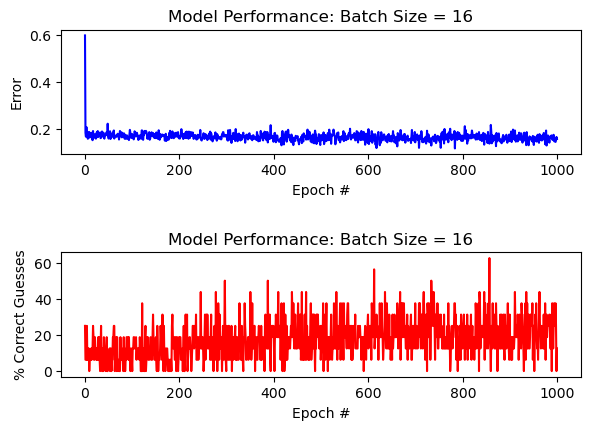

In [76]:
net.train_epochs(data, labels)